In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.signal import welch, savgol_filter, find_peaks
import os

sys.path.append(r"../src")
from preprocessing import butter_lowpass_filter

sys.path.append(r"../filter")
from MDN_bandstop import find_peak_properties_bandstop, remove_fundamental_and_harmonics, find_closest_peak_in_welch_spectrum, normalize_to_peak, compute_welch_spectrum
from EMD import emd 
from MDN_bandstop_prev import find_peak_properties_bandstop_prev, remove_fundamental_and_harmonics_fft_prev

→ Patient: p2
→ Phase: preswitch
→ Tijdvenster: 130s–190s
→ Amplitudebereik: 8–15 cmH₂O
354431 354431


<function matplotlib.pyplot.show(close=None, block=None)>

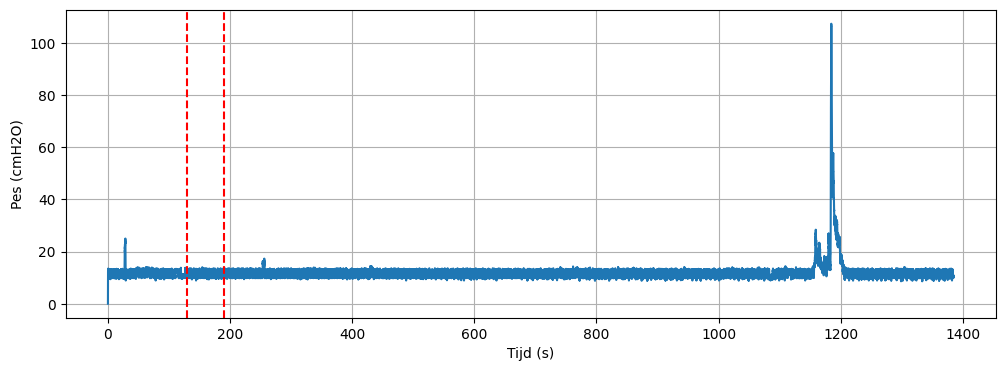

In [10]:
patient = "p2"  # p2, p4, p5, p6, p9, p10, p11, p12, p14, p15
phase = "preswitch" # 'preswitch' of 't30' of simulation

# --- Datasetdefinities ---
datasets_preswitch = [
    ("p2",  (8, 15),  (130, 190)),
    ("p4",  (10, 16), (520, 580)),
    ("p5",  (5, 15),  (800, 860)),
    ("p6",  (10, 18), (530, 590)),
    ("p9",  (8, 18),  (490, 550)),
    ("p10", (8, 20),  (730, 790)),
    ("p11", (9, 16),  (520, 580)),
    ("p12", (11, 19), (500, 560)),
    ("p14", (12, 23), (520, 580)),
    ("p15", (13, 25), (520, 580)),
]

datasets_t30 = [
    ("p2",  (9, 16),  (630, 690)),
    ("p4",  (2, 15),  (130, 190)),
    ("p5",  (0, 12),  (130, 190)),
    ("p6",  (-3, 13), (130, 190)),
    ("p9",  (10, 20), (180, 240)),
    ("p10", (2, 25),  (200, 260)),
    ("p11", (5, 32),  (300, 360)),
    ("p12", (5, 20),  (130, 190)),
    ("p14", (5, 16),  (110, 170)),
    ("p15", (10, 32), (500, 560)),
]

datasets_simulation = [
    ("p2",  (-20, 6),  (50,110)),
    ("p4",  (-20, 6),  (50,110)),
    ("p5",  (-20, 6),  (50,110)),
    ("p6",  (-20, 6),  (50,110)),
    ("p9",  (-20, 6),  (50,110)),
    ("p10", (-20, 6),  (50,110)),
    ("p11", (-20, 6),  (50,110)),
    ("p12", (-20, 6),  (50,110)),
    ("p14", (-20, 6),  (50,110)),
    ("p15", (-20, 6),  (50,110)),
]

# --- Selecteer juiste dataset ---
if phase == "preswitch":
    dataset = datasets_preswitch
elif phase == "t30":
    dataset = datasets_t30
elif phase == "simulation":
    dataset = datasets_simulation
else:
    raise ValueError(f"Onbekende phase: {phase}")

# --- Zoek patiëntinstellingen ---
match = next((d for d in dataset if d[0] == patient), None)

if match:
    ampl_low, ampl_high = match[1]
    t_start, t_end = match[2]
else:
    raise ValueError(f"Geen dataset gevonden voor patiënt {patient} in fase {phase}")

# --- Print ter controle ---
print(f"→ Patient: {patient}")
print(f"→ Phase: {phase}")
print(f"→ Tijdvenster: {t_start}s–{t_end}s")
print(f"→ Amplitudebereik: {ampl_low}–{ampl_high} cmH₂O")

data = np.load(rf"\\storage\v\vcl17\ICCL\DATA\Onderzoek\SWITCH-SAFE\Data\Kasper Gerhardt-Hansen\data\interim/{phase}/pes_data_{patient}.npz")
time, pes = data["time"], data["pes"]
print(len(time), len(pes))


plt.figure(figsize=(12, 4))
plt.plot(time, pes)
plt.xlabel("Tijd (s)")
plt.ylabel("Pes (cmH2O)")
plt.grid(True)


# tijd knippen 

mask = (time >= t_start) & (time <= t_end)

# time = time[mask]
# pes = pes[mask]

plt.axvline(t_start, color='r', linestyle='--')
plt.axvline(t_end, color='r', linestyle='--')
plt.show


## Preprocessing

In [11]:
pes = butter_lowpass_filter(pes, cutoff = 5) 
norm_pes = pes - np.mean(pes)  # Center de signalen rond nul

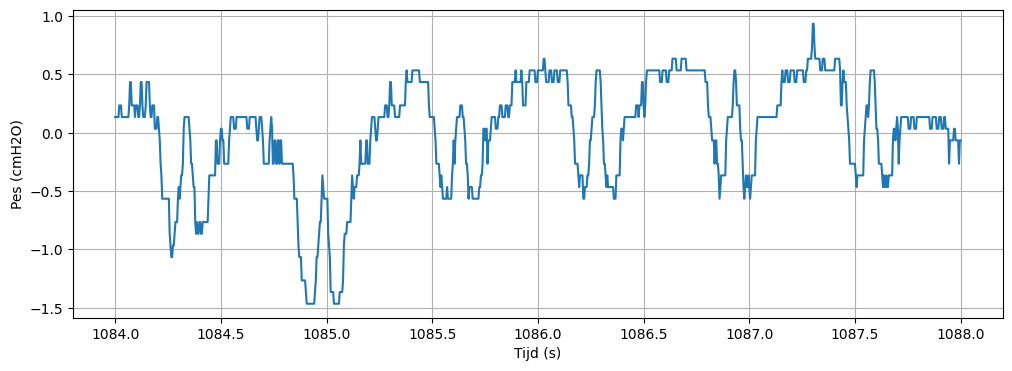

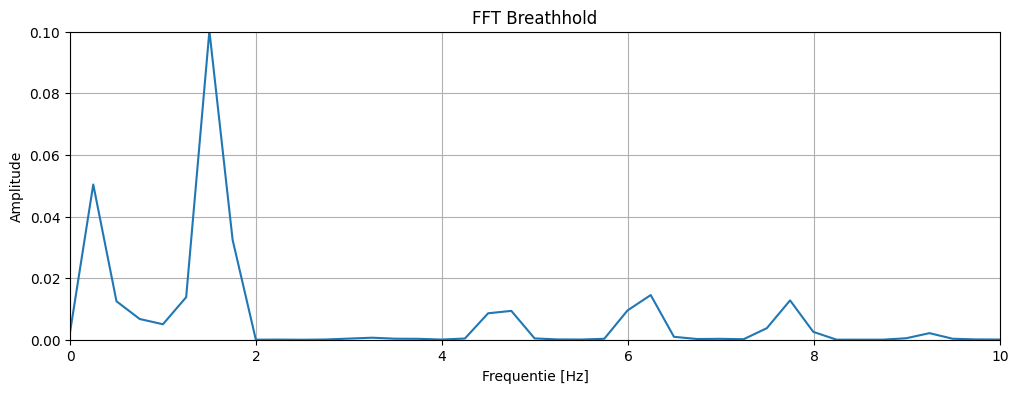

In [12]:
file_path = rf"\\storage\v\vcl17\ICCL\DATA\Onderzoek\SWITCH-SAFE\Data\Kasper Gerhardt-Hansen\data\interim/ademstops/pes_data_{patient}.npz"
data_ademstop = np.load(file_path)
interval_time = data_ademstop["time"]
interval_pes  = data_ademstop["pes"]
interval_pes = interval_pes - np.mean(interval_pes)

freqs_ademstop, mag_ademstop = compute_welch_spectrum(interval_pes)

plt.figure(figsize=(12, 4))
plt.plot(interval_time, interval_pes)
plt.xlabel("Tijd (s)")
plt.ylabel("Pes (cmH2O)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(freqs_ademstop, mag_ademstop)
plt.xlabel("Frequentie [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT Breathhold")
plt.grid(True)
plt.xlim(0, 10) 
plt.ylim(0, 0.1)
plt.show()

## Breath hold frequency detecion

Hoogste piek: 1.499 Hz, amplitude: 0.100, piekbreedte: 0.500 Hz


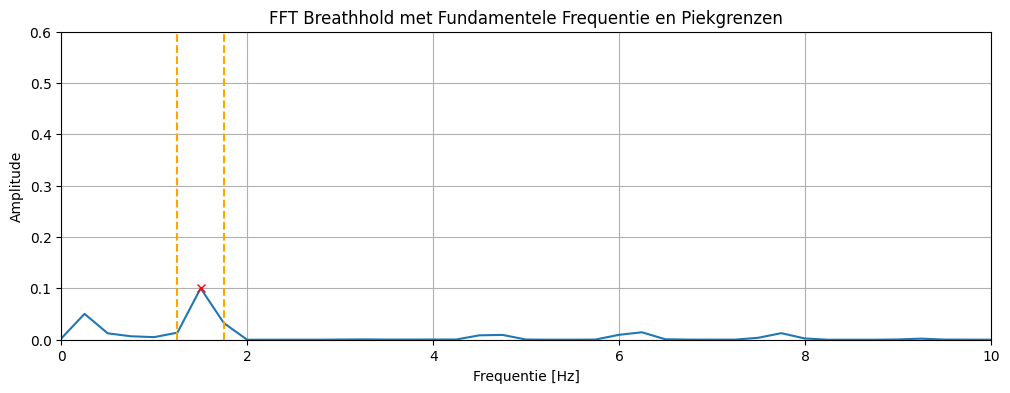

0.06147902743888024


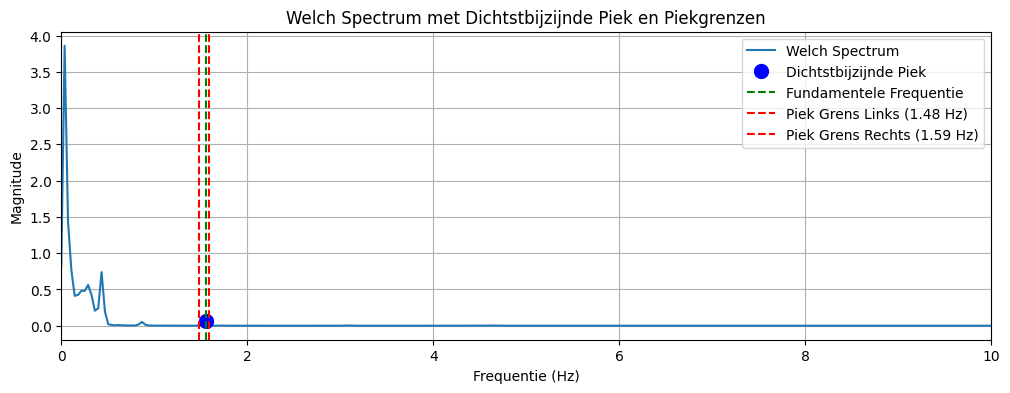

In [13]:
fundamental_freq_bh, fundamental_amp_bh, peak_width_bh, left_freq_bh, right_freq_bh = find_peak_properties_bandstop_prev(freqs_ademstop, mag_ademstop, f_min = 0.67, f_max=2.5)
bw_prev = peak_width_bh/2 + 0.25
MDN_filtered_prev, harmonics_prev= remove_fundamental_and_harmonics_fft_prev(pes, fundamental_freq_bh, bw=bw_prev)
print(f"Hoogste piek: {fundamental_freq_bh:.3f} Hz, amplitude: {fundamental_amp_bh:.3f}, piekbreedte: {peak_width_bh:.3f} Hz")
fundamental_freq, fundamental_amp, peak_width, left_freq, right_freq, freq, mag = find_closest_peak_in_welch_spectrum(norm_pes, fundamental_freq_bh)
# 40 bpm is minimale hartslag 
plt.figure(figsize=(12,4))
plt.plot(freqs_ademstop, mag_ademstop)
plt.plot(fundamental_freq_bh, fundamental_amp_bh, "rx")
# plt.plot(1.25, fundamental_amp, "rx")
plt.axvline(left_freq_bh, color="orange", linestyle="--")
plt.axvline(right_freq_bh, color="orange", linestyle="--")
plt.xlabel("Frequentie [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT Breathhold met Fundamentele Frequentie en Piekgrenzen")
plt.grid(True)
plt.xlim(0, 10)
plt.ylim(0, 0.6)
plt.show()
print(fundamental_amp)

plt.figure(figsize=(12,4))
plt.plot(freq, mag, label="Welch Spectrum")
plt.plot(fundamental_freq, fundamental_amp, 'bo', label="Dichtstbijzijnde Piek", markersize=10)
plt.axvline(fundamental_freq, color='g', linestyle='--', label="Fundamentele Frequentie")
plt.axvline(left_freq, color='r', linestyle='--', label=f"Piek Grens Links ({left_freq:.2f} Hz)")
plt.axvline(right_freq, color='r', linestyle='--', label=f"Piek Grens Rechts ({right_freq:.2f} Hz)")
plt.xlabel("Frequentie (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 10)
plt.title("Welch Spectrum met Dichtstbijzijnde Piek en Piekgrenzen")
plt.legend()
plt.grid(True)
plt.show()

## Fundamental frequency detection using EMD

In [14]:
if phase == 't30':
    #EMD detectie 
    imfs, residual = emd(pes, time, max_imfs=3, max_siftings=200, stop_std=0.05)
    norm_pes = pes - np.mean(pes)
    n_imfs = len(imfs)
    plt.figure(figsize=(12, 2*(n_imfs + 1)))
    plt.subplot(n_imfs + 1, 1, 1)
    plt.plot(time, pes, label='Noisy signal')
    plt.title('Oesophageal pressure - EMD')
    plt.legend()
    plt.grid(True)
    plt.xlim(t_start, t_end)
    plt.ylim(ampl_low, ampl_high)

    for i, imf in enumerate(imfs):
        plt.subplot(n_imfs + 1, 1, i + 2)
        plt.plot(time, imf)
        plt.title(f'IMF {i+1}')
        plt.grid(True)
        plt.xlim(t_start, t_end)

        


    plt.tight_layout()
    plt.show()

    N = len(pes)
    freq, mag = compute_welch_spectrum(norm_pes, fs=256)
    plt.figure(figsize=(12, 2*(n_imfs + 1)))
    plt.subplot(n_imfs + 1, 1, 1)
    plt.plot(freq, mag, label='Noisy signal')
    plt.title('Oesophageal pressure, Welch spectra')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 5)


    for i, imf in enumerate(imfs):
        
        freq, mag = compute_welch_spectrum(imf, fs=256)
        plt.subplot(n_imfs + 1, 1, i + 2)
        plt.plot(freq, mag)
        plt.title(f'IMF {i+1}')
        plt.grid(True)
        plt.xlim(0,5)


    plt.tight_layout()
    plt.show()


    # ---------------------------------------------------------
    # 1) Smooth PSD 
    # ---------------------------------------------------------
    def smooth_psd(mag):
        N = len(mag)
        wl = int(0.3 * N)      # 3% van PSD lengte
        wl = max(5, min(wl, 3))
        if wl % 2 == 0:
            wl += 1
        return savgol_filter(mag, wl, 3)


    # ---------------------------------------------------------
    # 2) Peak detection functie (los, niet geïntegreerd)
    # ---------------------------------------------------------
    def detect_peaks(freq, mag, fmin=0.67, fmax=4.0, min_prom_factor=0.1):
        mask = (freq >= fmin) & (freq <= fmax)
        f = freq[mask]
        m = mag[mask]
        m_large = m #relatief vergroten van de pieken
        prom = min_prom_factor * (np.max(m_large) - np.min(m_large))
        peaks, props = find_peaks(m_large, prominence=prom)

        return f, m, peaks, props


    # ---------------------------------------------------------
    # 3) PSD IMF1 + IMF2 
    # ---------------------------------------------------------
    freq1, mag1 = compute_welch_spectrum(imfs[0], fs=256)
    freq2, mag2 = compute_welch_spectrum(imfs[1], fs=256)
    freq3, mag3 = compute_welch_spectrum(imfs[2], fs=256)
    mag1 = normalize_to_peak(mag1)
    mag2 = normalize_to_peak(mag2)
    mag3 = normalize_to_peak(mag3)

    # ---------------------------------------------------------
    # 4) Smoothen
    # ---------------------------------------------------------
    mag1_sm = smooth_psd(mag1)
    mag2_sm = smooth_psd(mag2)
    mag3_sm = smooth_psd(mag3)

    # ---------------------------------------------------------
    # 5) Pieken detecteren
    # ---------------------------------------------------------
    f1, m1, peaks1, props1 = detect_peaks(freq1, mag1_sm)
    f2, m2, peaks2, props2 = detect_peaks(freq2, mag2_sm)
    f3, m3, peaks3, props3 = detect_peaks(freq3, mag3_sm)

    mag4_sm = mag1_sm + mag2_sm - mag3_sm
    f4, m4, peaks4, props4 = detect_peaks(freq1, mag4_sm)
    # ---------------------------------------------------------
    # 6) Fundamentele frequentie bepalen
    # ---------------------------------------------------------
    if len(peaks1) == 0:
        print("⚠️ Geen pieken gevonden in IMF1.")
        fundamental_freq = None
    else:
        fundamental_freq = f4[peaks4[0]]
        print("Fundamentele hartfrequentie:", fundamental_freq, "Hz")
        print("≈", fundamental_freq * 60, "BPM")

        # check IMF2 bevestiging
        if len(peaks2) > 0:
            imf2_freqs = f2[peaks2]
            if np.any(np.abs(imf2_freqs - fundamental_freq) < 0.1):
                print("→ Bevestigd door IMF2 (peak at same frequency)")
            else:
                print("→ Niet bevestigd door IMF2")


    # ---------------------------------------------------------
    # 7) PLOTTING
    # ---------------------------------------------------------

    plt.figure(figsize=(12, 8))

    # --- IMF1 PSD ---
    plt.subplot(4, 1, 1)
    plt.plot(freq1, mag1, alpha=0.4, label="Raw PSD IMF1")
    plt.plot(freq1, mag1_sm, linewidth=2, label="Smoothed PSD IMF1")

    if fundamental_freq is not None:
        plt.axvline(fundamental_freq, color='r', linestyle='--', label=f"Fundamental = {fundamental_freq:.2f} Hz")

    plt.scatter(f1[peaks1], m1[peaks1], color='red', label="Detected peaks")
    plt.title("IMF1 PSD")
    plt.grid(True)
    plt.xlim(0, 5)
    plt.legend()

    # --- IMF2 PSD ---
    plt.subplot(4, 1, 2)
    plt.plot(freq2, mag2, alpha=0.4, label="Raw PSD IMF2")
    plt.plot(freq2, mag2_sm, linewidth=2, label="Smoothed PSD IMF2")

    plt.scatter(f2[peaks2], m2[peaks2], color='red', label="Detected peaks")
    plt.title("IMF2 PSD")
    plt.grid(True)
    plt.xlim(0, 5)
    plt.legend()

    # --- IMF3 PSD ---
    plt.subplot(4, 1, 3)
    plt.plot(freq3, mag3, alpha=0.4, label="Raw PSD IMF2")
    plt.plot(freq3, mag3_sm, linewidth=2, label="Smoothed PSD IMF3")

    plt.scatter(f3[peaks3], m3[peaks3], color='red', label="Detected peaks")
    plt.title("IMF3 PSD")
    plt.grid(True)
    plt.xlim(0, 5)
    plt.legend()

    # --- IMF1+2-3 PSD ---
    plt.subplot(4, 1, 4)
    plt.plot(freq2, mag4_sm, linewidth=2, label="Smoothed PSD IMF1+2-3")

    plt.scatter(f4[peaks4], m4[peaks4], color='red', label="Detected peaks")
    plt.title("IMF1+2-3 PSD")
    plt.grid(True)
    plt.xlim(0, 5)
    plt.legend()

    plt.tight_layout()
    plt.show()

    if fundamental_freq is None: 
        file_path = rf"/Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/data/interim/ademstops/pes_data_{patient}.npz"
        data_ademstop = np.load(file_path)
        interval_time = data_ademstop["time"]
        interval_pes  = data_ademstop["pes"]
        interval_pes = interval_pes - np.mean(interval_pes)

        freqs_ademstop, mag_ademstop = compute_welch_spectrum(interval_pes)

        fundamental_freq_bh, fundamental_amp_bh, peak_width_bh, left_freq_bh, right_freq_bh = find_peak_properties_bandstop(freqs_ademstop, mag_ademstop, f_min = 0.67, f_max=2.5)
        norm_pes = pes - np.mean(pes) 
        fundamental_freq, fundamental_amp, peak_width, left_freq, right_freq, freq, mag = find_closest_peak_in_welch_spectrum(norm_pes, fundamental_freq_bh)
        print("Geen fundamentele frequentie gevonden, dus passen breathhold toe")


## Apply filtering

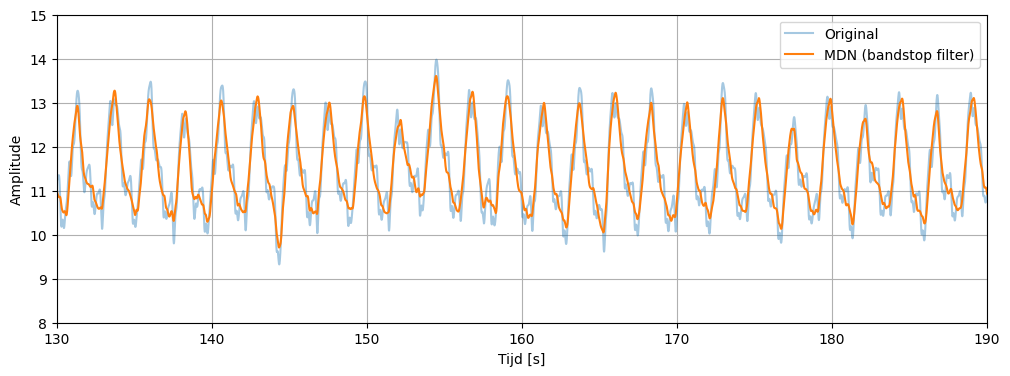

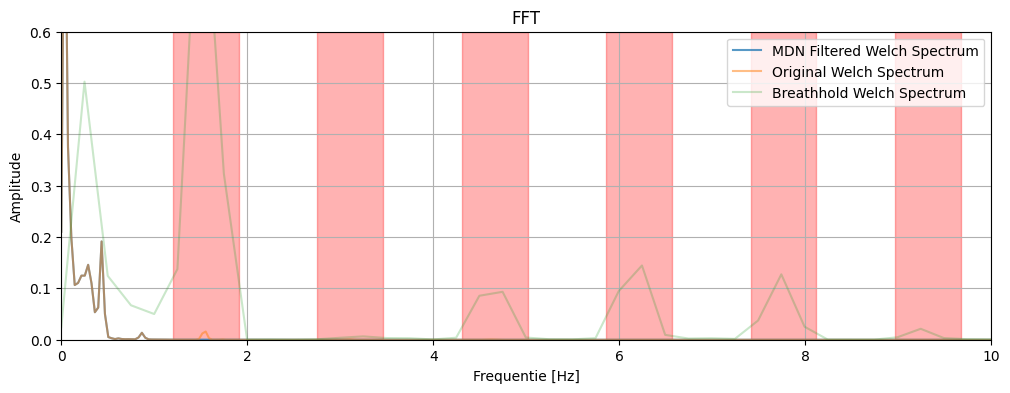

In [15]:
if peak_width > peak_width_bh:
    peak_width = peak_width_bh
    print(f"Adjusted peak width to breathhold peak width: {peak_width_bh} Hz")
bw = peak_width/2+0.3   #margin of 0.25 Hz


MDN_filtered, harmonics = remove_fundamental_and_harmonics(pes, fundamental_freq, bw=bw)

plt.figure(figsize=(12,4))
plt.plot(time, pes, alpha=0.4, label="Original")
plt.plot(time, MDN_filtered, label="MDN (bandstop filter)")
plt.xlabel("Tijd [s]")
plt.ylabel("Amplitude")
plt.xlim(t_start, t_end)
plt.ylim(ampl_low, ampl_high)
plt.legend()
plt.grid(True)
plt.show()

freqs_MDN2, mag_MDN2 = compute_welch_spectrum(MDN_filtered)
freq, mag = compute_welch_spectrum(pes)
mag_MDN2 = normalize_to_peak(mag_MDN2)
mag = normalize_to_peak(mag)
mag_ademstop = normalize_to_peak(mag_ademstop)
plt.figure(figsize=(12,4))
plt.plot(freqs_MDN2, mag_MDN2, alpha=0.75, label="MDN Filtered Welch Spectrum")
for h in harmonics:
    plt.axvspan(h - bw, h + bw, color='red', alpha=0.3)
plt.plot(freq, mag, alpha=0.5, label="Original Welch Spectrum")
plt.plot(freqs_ademstop, mag_ademstop, alpha=0.25, label="Breathhold Welch Spectrum")
plt.xlabel("Frequentie [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT")
plt.grid(True)
plt.xlim(0, 10)
plt.ylim(0, 0.6)
plt.legend()
plt.show()

## Opslaan

In [8]:
# --- Basis directories ---
signals_dir = rf"/Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/data/processed/{phase}"
figures_dir = rf"/Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/output/figures/{phase}"

os.makedirs(signals_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# --- MDN filtering met verschillende bw ---
bw_offsets = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
MDN_signals = {}
MDN_harmonics = {}
for offset in bw_offsets:
    bw_var = peak_width/2 + offset
    MDN_filtered_var, harmonics_var = remove_fundamental_and_harmonics(pes, fundamental_freq, bw=bw_var)
    label = f"MDN_BS_bw_{offset:+.2f}"
    MDN_signals[label] = MDN_filtered_var
    MDN_harmonics[label] = {'harmonics': harmonics_var, 'bw': bw_var}

MDN_signals["Previous_BS_method"] = MDN_filtered_prev
MDN_harmonics["Previous_BS_method"] = {
    "harmonics": harmonics_prev,
    "bw": bw_prev
}
# --- PRESWITCH of T30 DATA ---
if phase in ["preswitch", "t30"]:
    # --- Signalen opslaan in dictionary ---
    signals_data = {
        "time": time,
        "pes": pes
        # "Previous_BS_method": MDN_filtered_prev
    }
    signals_data.update(MDN_signals)

    # --- Opslaan naar .npz ---
    file_path = os.path.join(signals_dir, rf"filtered_signals_{patient}.npz")
    np.savez(file_path, **signals_data)
    print(f"Signalen opgeslagen in: {file_path}")

    # --- Tijdsdomein figuur ---
    signals_to_plot = (
    [("Original", pes)]
    + [(label, sig) for label, sig in MDN_signals.items()])
    fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(15, 12), sharex=True)

    for ax, (label, sig) in zip(axes, signals_to_plot):
        ax.plot(time, pes, color='gray', alpha=0.5)
        ax.plot(time, sig, color='red', label=label)
        ax.legend(loc="upper right", fontsize=12)
        ax.grid(True)
        ax.set_xlim(t_start, t_end)
        ax.set_ylim(ampl_low, ampl_high)

    axes[-1].set_xlabel("Time [s]", fontsize=12)
    axes[len(signals_to_plot)//2].set_ylabel("Amplitude", fontsize=12)
    plt.tight_layout()

    fig_path = os.path.join(figures_dir, rf"{phase}_{patient}_tijd.png")
    fig.savefig(fig_path, dpi=300)
    plt.close(fig)
    print(f"Tijdsdomein figuur opgeslagen in: {fig_path}")

    # --- Welch figuur ---
    fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(15, 12), sharex=True)

    for ax, (label, sig) in zip(axes, signals_to_plot):
        freqs, mag = compute_welch_spectrum(sig)
        mag = normalize_to_peak(mag)
        
        # Origineel signaal in grijs
        freqs_noisy, mag_noisy = compute_welch_spectrum(pes)
        mag_noisy = normalize_to_peak(mag_noisy)
        ax.plot(freqs_noisy, mag_noisy, color='gray', alpha=0.5)
        
        # Gefilterd signaal in rood
        ax.plot(freqs, mag, color='red', label=label)
        
        # Harmonischen markeren als ze bestaan
        if label in MDN_harmonics:
            harmonics = MDN_harmonics[label]['harmonics']
            bw = MDN_harmonics[label]['bw']
            if label == "Previous_BS_method":
                span_color = "blue"
                span_alpha = 0.25
            else:
                span_color = "red"
                span_alpha = 0.3
            for h in harmonics:
                ax.axvspan(h - bw, h + bw, color=span_color, alpha=span_alpha)
        
        ax.legend(loc="upper right", fontsize=12)
        ax.grid(True)
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 0.15)

    axes[-1].set_xlabel("Frequency [Hz]", fontsize=12)
    axes[len(signals_to_plot)//2].set_ylabel("Amplitude", fontsize=12)
    plt.tight_layout()

    fig_path = os.path.join(figures_dir, rf"{phase}_{patient}_welchspectrum.png")
    fig.savefig(fig_path, dpi=300)
    plt.close(fig)
    print(f"Welch figuur opgeslagen in: {fig_path}")



# --- SIMULATIE DATA ---
elif phase == "simulation":
    # --- Signalen opslaan in dictionary ---
    clean_pes = data["clean_pes"]
    signals_data = {
        "time": time,
        "pes": pes,
        "clean_pes": clean_pes
        # "Previous_BS_method": MDN_filtered_prev
    }
    signals_data.update(MDN_signals)

    # --- Opslaan naar .npz ---
    file_path = os.path.join(signals_dir, rf"filtered_signals_{patient}.npz")
    np.savez(file_path, **signals_data)
    print(f"Signalen opgeslagen in: {file_path}")

    # --- Tijdsdomein figuur ---
    signals_to_plot = [("Original", pes)] + [(label, sig) for label, sig in MDN_signals.items()]
    fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(15, 12), sharex=True)

    for ax, (label, sig) in zip(axes, signals_to_plot):
        ax.plot(time, pes, color='gray', alpha=0.5)
        ax.plot(time, clean_pes, color='blue', alpha=0.5)
        ax.plot(time, sig, color='red', label=label)
        ax.legend(loc="upper right", fontsize=12)
        ax.grid(True)
        ax.set_xlim(t_start, t_end)
        ax.set_ylim(ampl_low, ampl_high)

    axes[-1].set_xlabel("Time [s]", fontsize=12)
    axes[len(signals_to_plot)//2].set_ylabel("Amplitude", fontsize=12)
    plt.tight_layout()

    fig_path = os.path.join(figures_dir, rf"{phase}_{patient}_tijd.png")
    fig.savefig(fig_path, dpi=300)
    plt.close(fig)
    print(f"Tijdsdomein figuur opgeslagen in: {fig_path}")

    # --- Welch figuur ---
    fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(15, 12), sharex=True)

    for ax, (label, sig) in zip(axes, signals_to_plot):
        freqs, mag = compute_welch_spectrum(sig)
        mag = normalize_to_peak(mag)
        
        # Origineel en clean signaal
        freqs_noisy, mag_noisy = compute_welch_spectrum(pes)
        mag_noisy = normalize_to_peak(mag_noisy)
        freqs_clean, mag_clean = compute_welch_spectrum(clean_pes)
        mag_clean = normalize_to_peak(mag_clean)
        
        ax.plot(freqs_noisy, mag_noisy, color='gray', alpha=0.5)
        ax.plot(freqs_clean, mag_clean, color='blue', alpha=0.5)
        ax.plot(freqs, mag, color='red', label=label)
        
        # Harmonischen markeren
        if label in MDN_harmonics:
            harmonics = MDN_harmonics[label]['harmonics']
            bw = MDN_harmonics[label]['bw']
            if label == "Previous_BS_method":
                span_color = "blue"
                span_alpha = 0.25
            else:
                span_color = "red"
                span_alpha = 0.3
            for h in harmonics:
                ax.axvspan(h - bw, h + bw, color=span_color, alpha=span_alpha)
        
        ax.legend(loc="upper right", fontsize=12)
        ax.grid(True)
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 0.15)

    axes[-1].set_xlabel("Frequency [Hz]", fontsize=12)
    axes[len(signals_to_plot)//2].set_ylabel("Amplitude", fontsize=12)
    plt.tight_layout()

    fig_path = os.path.join(figures_dir, rf"{phase}_{patient}_welchspectrum.png")
    fig.savefig(fig_path, dpi=300)
    plt.close(fig)
    print(f"Welch figuur opgeslagen in: {fig_path}")

Signalen opgeslagen in: /Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/data/processed/preswitch\filtered_signals_p2.npz
Tijdsdomein figuur opgeslagen in: /Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/output/figures/preswitch\preswitch_p2_tijd.png
Welch figuur opgeslagen in: /Volumes/Onderzoek/SWITCH-SAFE/Data/Lucas Naessens/Project_TMII_filtering_Pes/output/figures/preswitch\preswitch_p2_welchspectrum.png
